# Day 1 — From Machine Learning to Deep Learning

## Note 1.1 — Where Machine Learning Runs Out of Road

## Learning Goal & Outcome

**Goal.** Understand what genuinely changes when a model learns its own representations instead of consuming features that you engineered by hand.

**Outcome.** By the end of this note you can state precisely what deep learning buys you — and, just as importantly, name the situations where it buys you nothing at all. You will have seen both cases with your own data and your own numbers.


## Objectives

By the end of this note you will be able to:

- explain why neural networks exist, in terms of the ML pipeline you already know;
- distinguish a **learned parameter** from an **engineered feature**;
- describe the classical ML pipeline and the deep learning pipeline, and identify exactly where they diverge;
- identify problem types where classical ML remains the correct professional choice in 2026;
- explain why raw pixels and raw text defeat manual feature engineering;
- state where feature engineering still lives inside modern deep learning.


## Dataset Used

| Dataset | Modality | Role in this note | Source |
|---|---|---|---|
| **Two Spirals** | Synthetic 2-D | The problem a linear model cannot solve | Generated in-notebook, no download |
| **Telco Customer Churn** (7,043 rows, 21 columns) | Tabular | The honest counterexample — where gradient boosting wins | Public raw CSV, no auth required |
| **`sklearn.load_digits`** (1,797 images, 8×8) | Image | Why raw pixels break manual feature engineering | Bundled with scikit-learn, no download |

All three run comfortably on CPU. Nothing in this note requires a GPU.

## Table of Contents

1. [Where we are in the course](#s1)
2. [A problem your current toolkit should handle](#s2)
3. [Two spirals, and a linear model that cannot](#s3)
4. [Fixing it by hand: engineering the features yourself](#s4)
5. [Who invented those features?](#s5)
6. [A small network finds them on its own](#s6)
7. [The honest counterexample: churn, where the network wins nothing](#s7)
8. [What actually changed](#s8)
9. [Where feature engineering still lives in deep learning](#s9)
10. [Raw pixels: the point of no return](#s10)
11. [What this course is, and what it is not](#s11)
12. [Conclusion](#s12)

## Setup

Run this once. Everything in this note is CPU-only, but we check for an accelerator now because Notes 1.2 and 1.3 will use one if it exists.

In [32]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [42]:
# Pinned for reproducibility. If a version differs on your machine, the code still runs,
# but numbers may shift slightly in the last decimal place.
# numpy>=2.0  pandas>=2.2  scikit-learn>=1.5  matplotlib>=3.8  torch>=2.4

import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

print(f"python       {sys.version.split()[0]}")
print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"scikit-learn {sklearn.__version__}")

# --- accelerator detection (used from Note 1.3 onward) ---
try:
    import torch
    if torch.cuda.is_available():
        DEVICE = "cuda"
    elif torch.backends.mps.is_available():
        DEVICE = "mps"
    else:
        DEVICE = "cpu"
    print(f"torch        {torch.__version__}  ->  device: {DEVICE}")
except ImportError:
    DEVICE = "cpu"
    print("torch        not installed yet (needed from Note 1.3)")

python       3.13.9
numpy        2.3.5
pandas       2.3.3
scikit-learn 1.7.2
torch        2.14.0  ->  device: mps


## 1. Where we are in the course

You arrive at this course already able to do a great deal. You can load a messy dataset, clean it, explore it, encode categoricals, split it properly, fit a model, tune it, and evaluate it honestly. That is not a small skill set. Most of what follows depends on it.

So it is worth being precise about what is actually new here, because the honest answer is narrower than the marketing suggests.

In everything you have built so far, **you decided what the model would look at.** You chose the columns. You created the ratios, the log transforms, the interaction terms, the aggregations over time windows. The learning algorithm optimised coefficients or split points, but the *description* of each example — the thing the algorithm actually consumed — came from your judgement.

Deep learning moves that description inside the model. The network is handed something closer to the raw signal and learns, as part of the same optimisation that fits the final prediction, what the useful intermediate descriptions are.

That single shift is what this entire course is built on, and it is what makes foundation models possible. Here is the road ahead:

<div align="center">

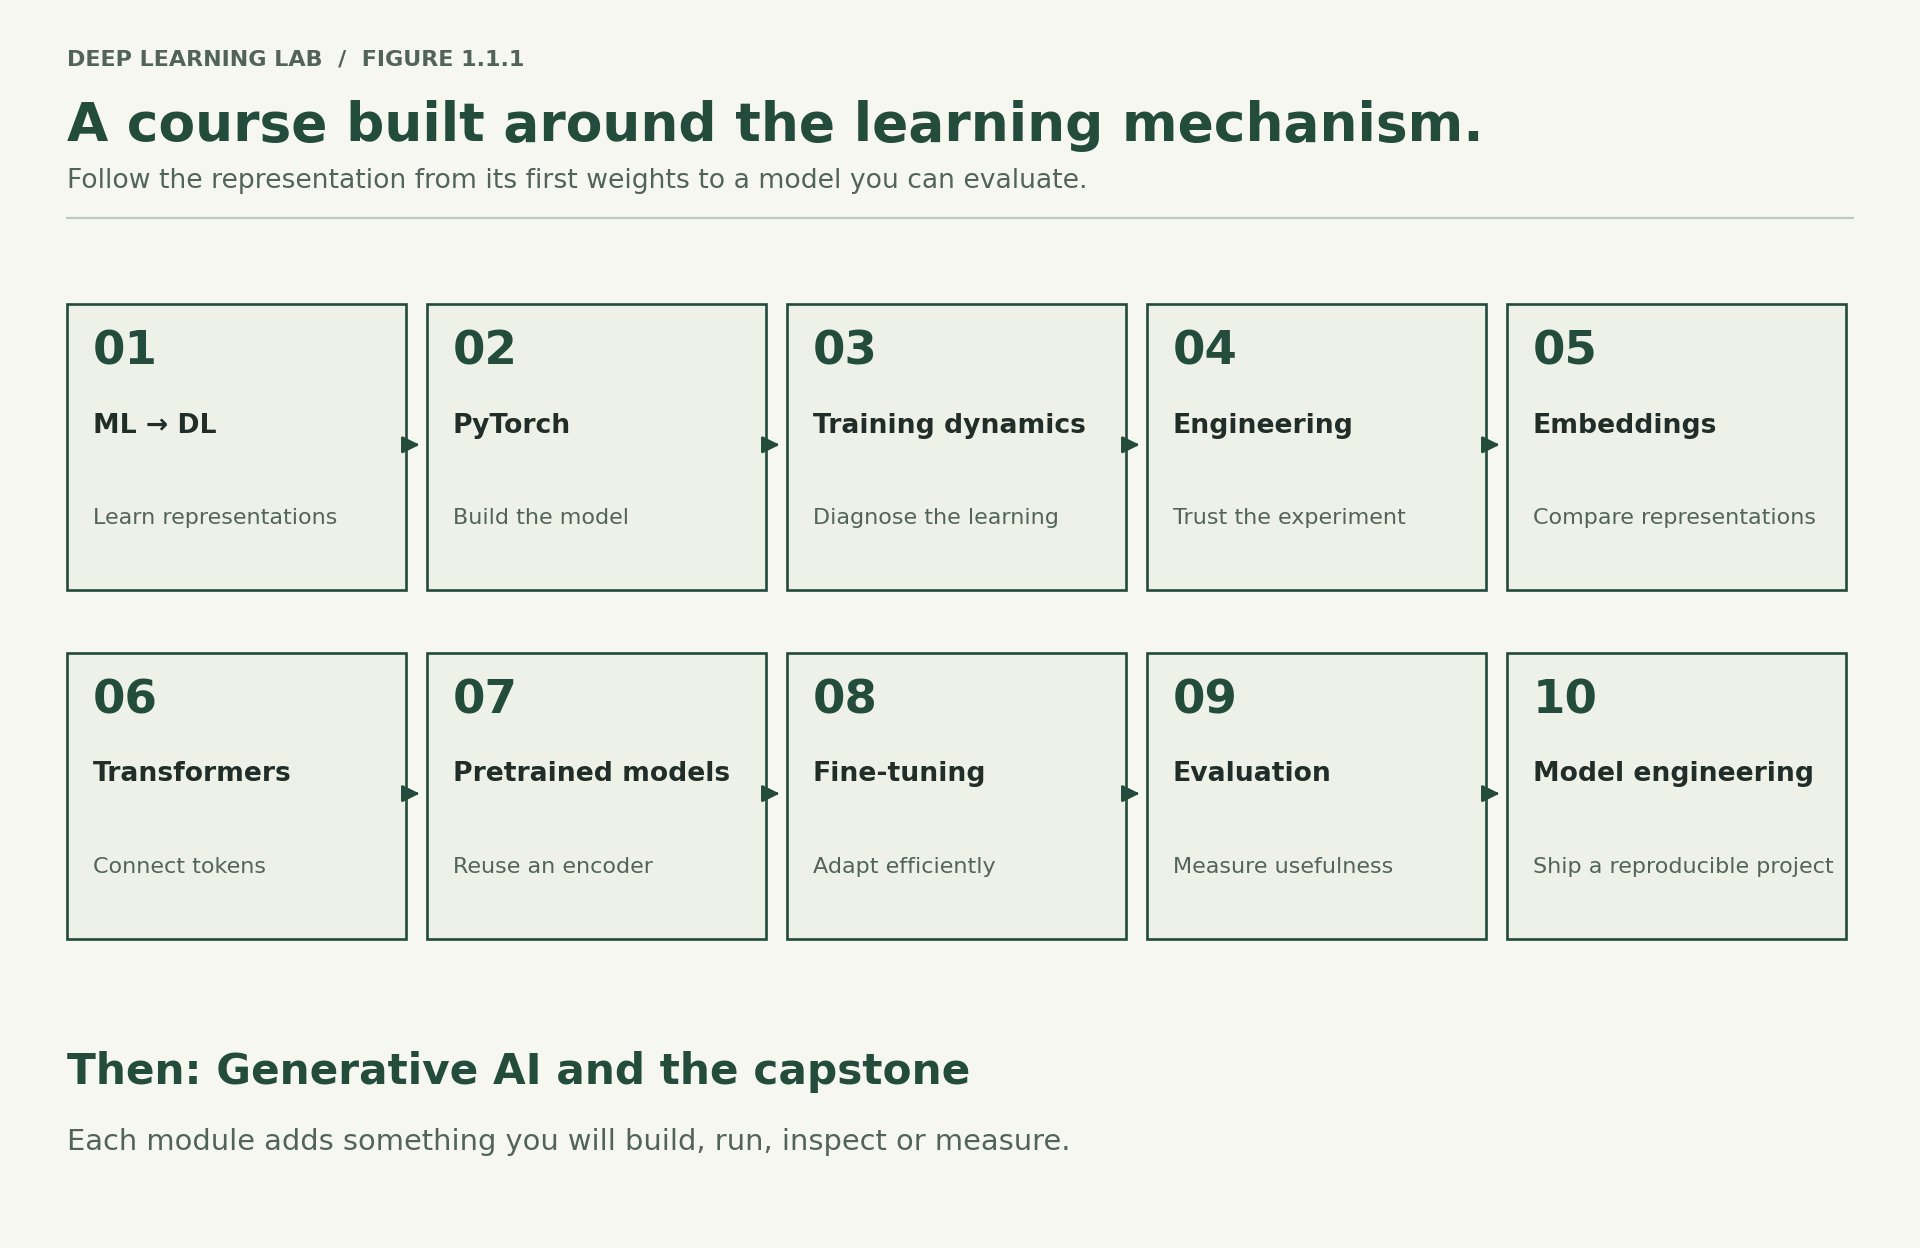

<p><b>Figure 1.1.1.</b> The ten Deep Learning Lab modules, followed by Generative AI and the capstone. Read each row left to right.</p>

</div>

You are at the far left. By Day 10 you will be at the far right, and each arrow will be something you have actually run.

<div align="center">

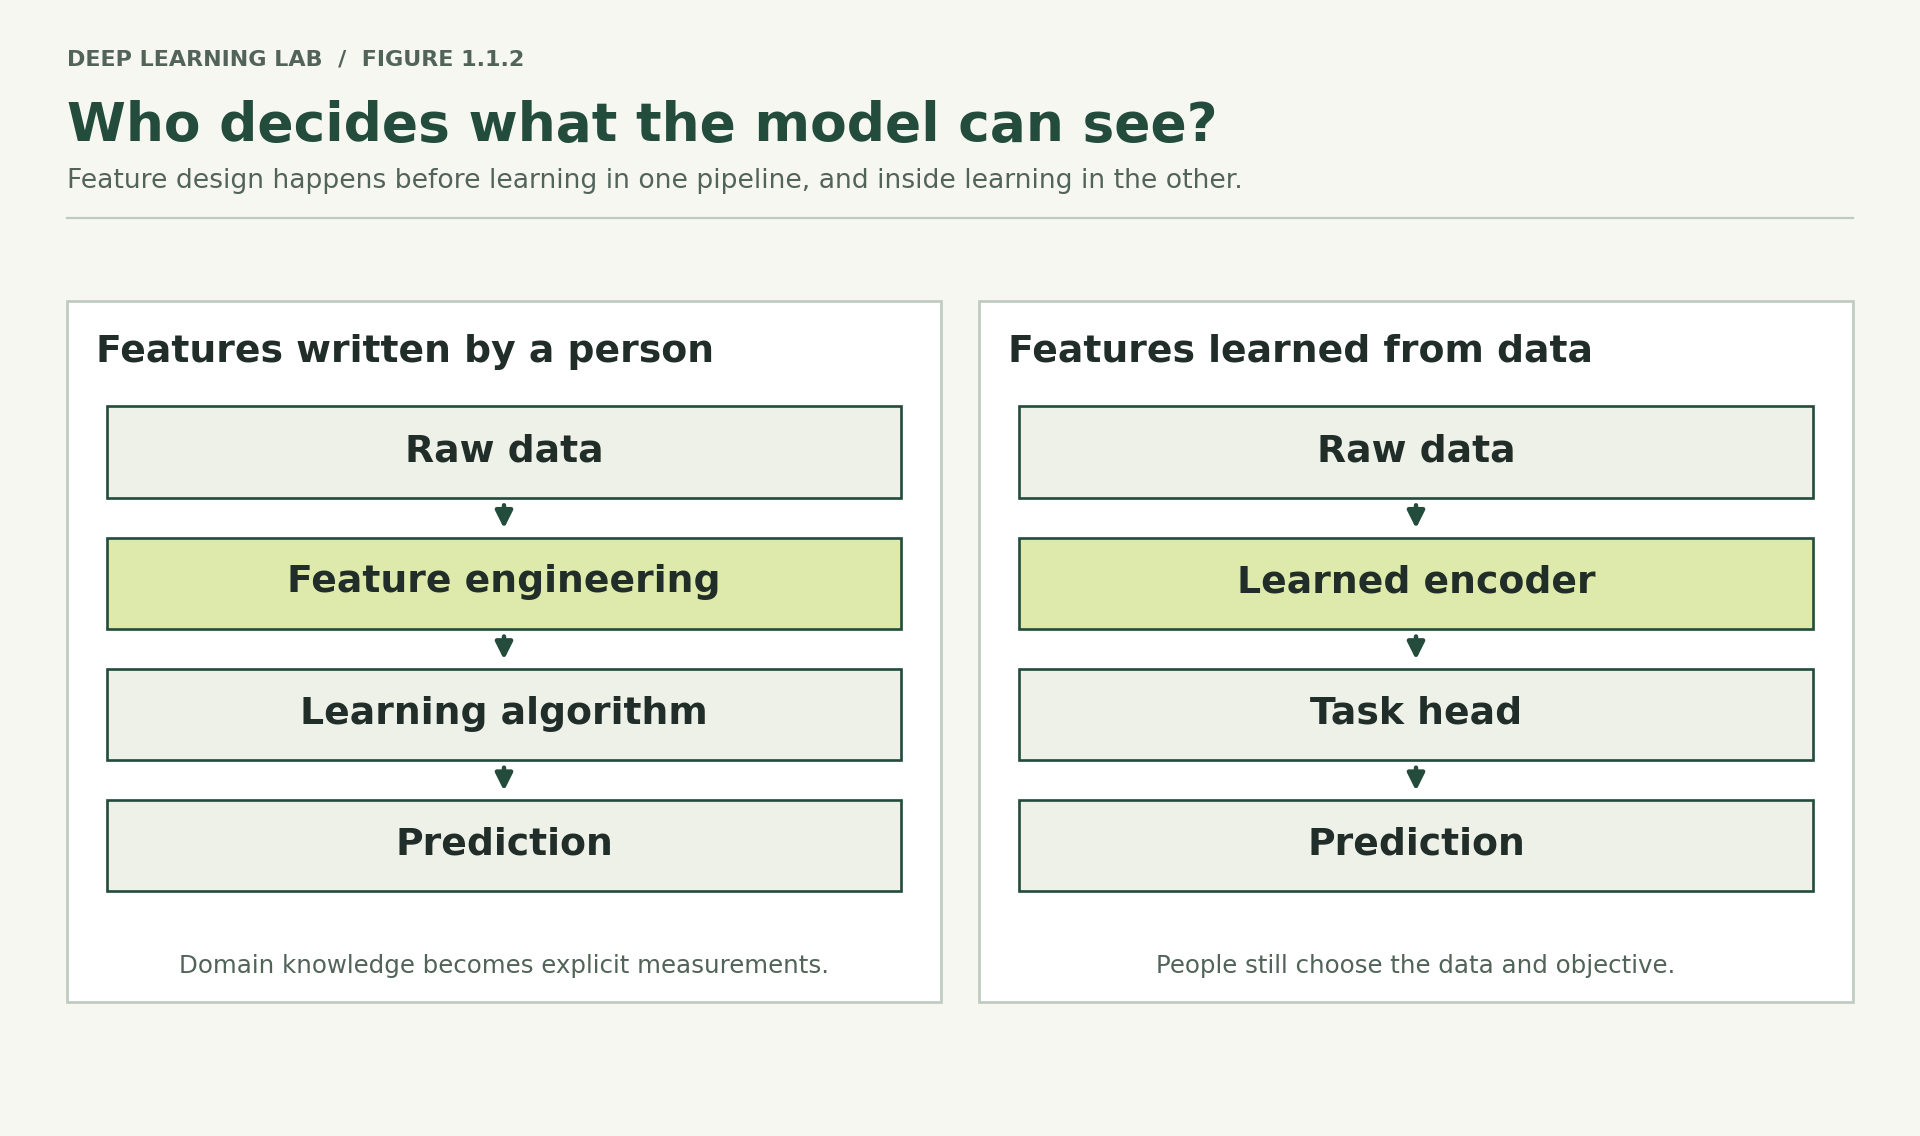

<p><b>Figure 1.1.2.</b> Both pipelines learn to make predictions. Representation learning also learns the feature transformation; people still choose data, architecture and objective.</p>

</div>

**Think before you continue.** Name one feature you engineered in a past project that took real domain knowledge to invent. Could a model plausibly have discovered it from raw data? What would it have needed in order to do so?

## 2. A problem your current toolkit should handle

Rather than argue about pipelines in the abstract, let us construct a problem where the difference becomes visible in a single plot.

The problem is deliberately tiny: two features, two classes, one thousand points. There is no missing data, no leakage, no class imbalance, no categorical encoding to worry about. Every complication you normally spend your time on has been removed. Only the shape of the decision boundary remains.

That is the point. When a model fails here, there is nowhere to hide.

In [43]:
def make_spirals(n_per_class=500, noise=0.04, revolutions=2.5, seed=SEED):
    """Two interleaved spiral arms, one per class.

    Returns
    -------
    X : (2*n_per_class, 2) float array of coordinates
    y : (2*n_per_class,)   int array of class labels {0, 1}
    """
    rng = np.random.default_rng(seed)
    Xs, ys = [], []
    for c in range(2):
        # sqrt() spreads points evenly over area rather than bunching them at the centre
        t = np.sqrt(rng.random(n_per_class)) * revolutions * 2 * np.pi
        r = t / (revolutions * 2 * np.pi)          # radius grows from 0 to 1
        theta = t + c * np.pi                       # second arm is rotated half a turn
        x1 = r * np.cos(theta) + rng.normal(0, noise, n_per_class)
        x2 = r * np.sin(theta) + rng.normal(0, noise, n_per_class)
        Xs.append(np.stack([x1, x2], axis=1))
        ys.append(np.full(n_per_class, c))
    X = np.vstack(Xs)
    y = np.concatenate(ys)
    perm = rng.permutation(len(y))
    return X[perm], y[perm]


REVOLUTIONS = 2.5
X, y = make_spirals(revolutions=REVOLUTIONS)
print("X shape:", X.shape, " y shape:", y.shape, " class balance:", np.bincount(y))

X shape: (1000, 2)  y shape: (1000,)  class balance: [500 500]


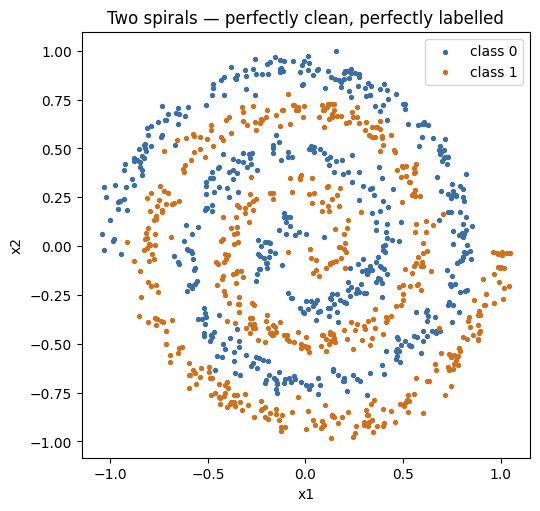

In [44]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(X[y == 0, 0], X[y == 0, 1], s=8, c="#3b6ea5", label="class 0")
ax.scatter(X[y == 1, 0], X[y == 1, 1], s=8, c="#d1701c", label="class 1")
ax.set_title("Two spirals — perfectly clean, perfectly labelled")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

Look at it for a moment before moving on. A human sees the structure instantly. The two arms are obvious, the rule separating them is obvious, and you could label a new point by eye without hesitation.

Hold onto that, because the model is about to fail at something you can do effortlessly.

**Question.** If you had to describe the separating rule in words to a colleague, what would you say? Notice that your description almost certainly involves *distance from the centre* and *angle*, not x1 and x2 directly. Remember that — it becomes important in Section 4.

## 3. Two spirals, and a linear model that cannot

A logistic regression draws exactly one straight line through your feature space. Every point on one side receives one label, every point on the other side receives the other. That constraint is not a weakness in the implementation, not a bug, and not something a better optimiser would fix. It is the definition of the model.

Now look again at what we are asking it to separate. Walk outward along either spiral arm and you cross from one class to the other, repeatedly. No single straight line survives that journey. You have been handed a straight ruler and asked to trace a coil.

<div align="center">

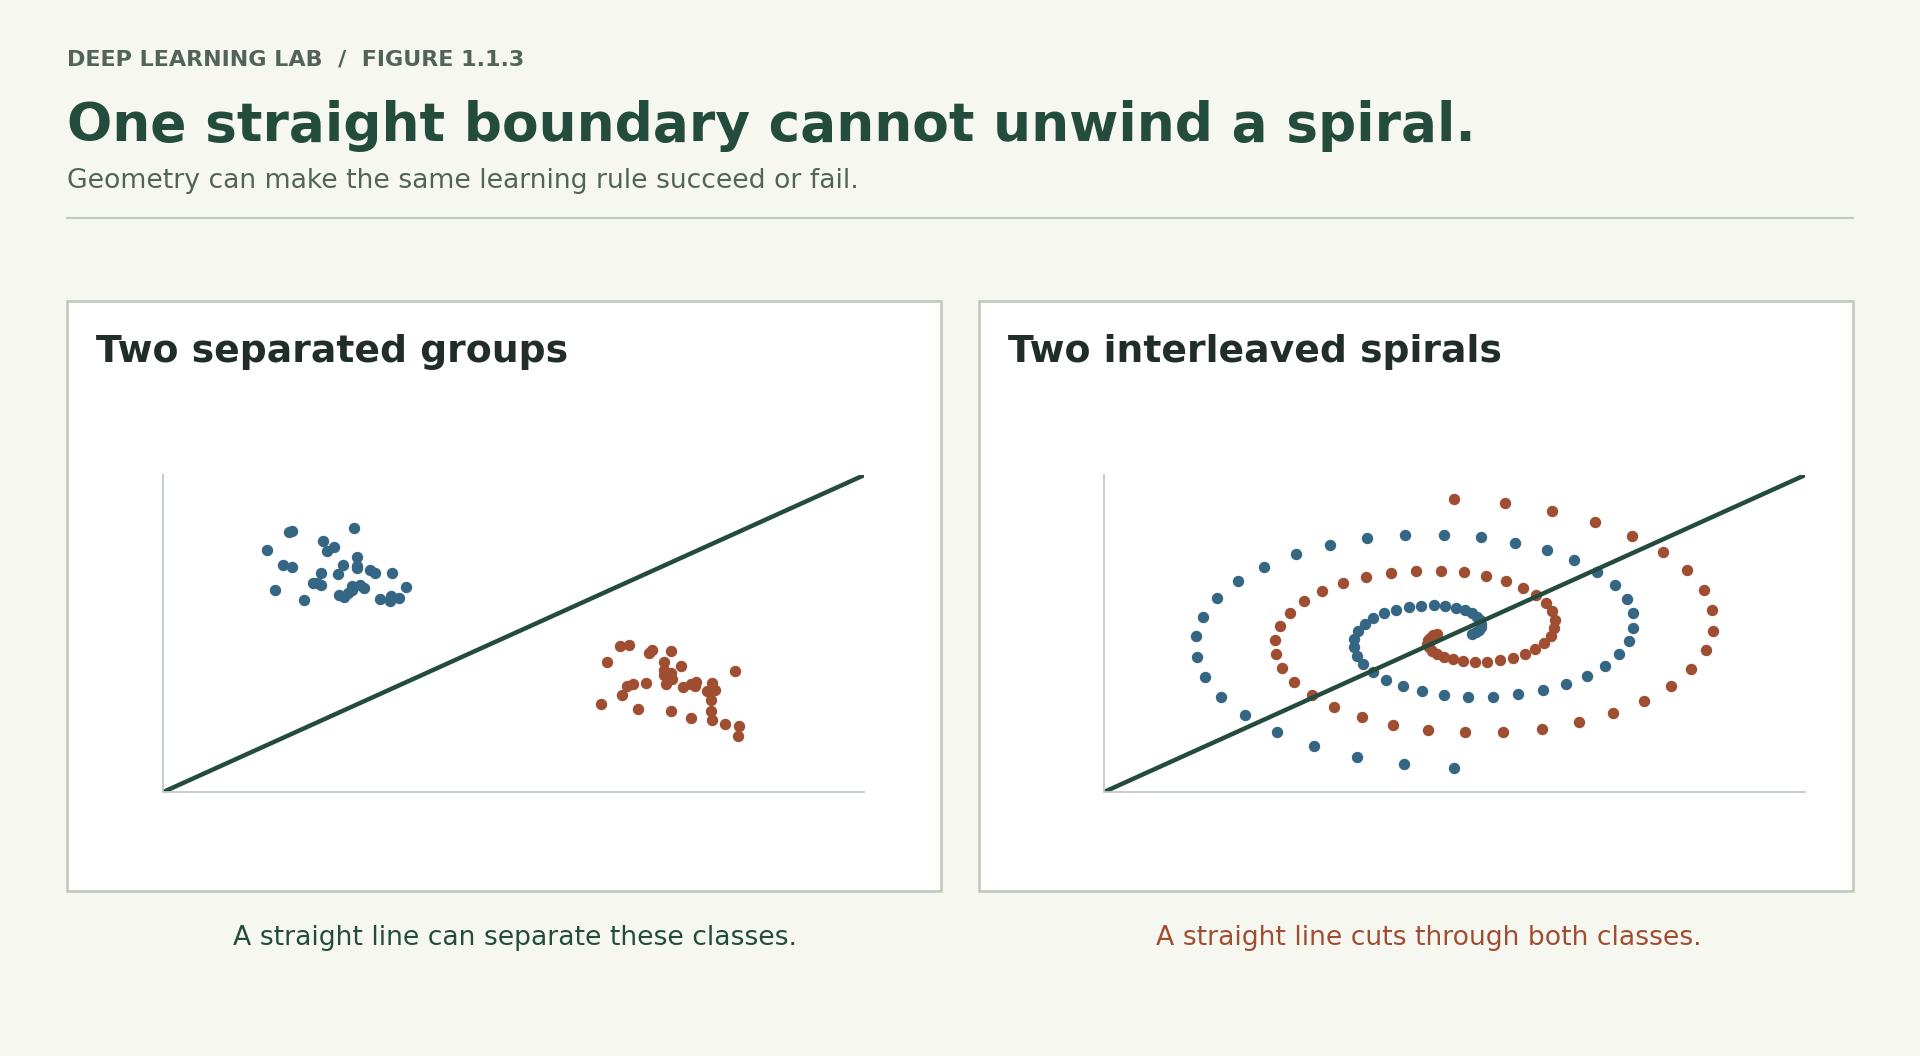

<p><b>Figure 1.1.3.</b> Schematic data geometry: a linear separator suits separated groups but not interleaved spirals. These points illustrate the concept, not a measured experiment.</p>

</div>

Before you run the next cell, commit to a number. What test accuracy do you expect?

In [45]:
X

array([[-0.55116798, -0.37382426],
       [ 0.1575606 ,  0.99847351],
       [-0.0345203 ,  0.07294894],
       ...,
       [-0.98668837,  0.02703767],
       [ 0.96692115, -0.14480294],
       [ 1.04025859, -0.2036717 ]], shape=(1000, 2))

In [46]:
y

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

In [48]:
X_train

array([[-0.37011545,  0.38877092],
       [-0.454673  , -0.20032154],
       [ 0.47800824, -0.21109596],
       ...,
       [-0.06792554,  0.27678796],
       [ 0.37904385,  0.40279626],
       [ 0.38958808, -0.18715052]], shape=(750, 2))

In [49]:
linear = LogisticRegression().fit(X_train, y_train)
acc_linear = accuracy_score(y_test, linear.predict(X_test))
print(f"Logistic regression on raw (x1, x2):  test accuracy = {acc_linear:.3f}")

Logistic regression on raw (x1, x2):  test accuracy = 0.592


In [40]:
print(f"Always-predict-majority baseline:     test accuracy = {max(np.bincount(y_test)) / len(y_test):.3f}")

Always-predict-majority baseline:     test accuracy = 0.500


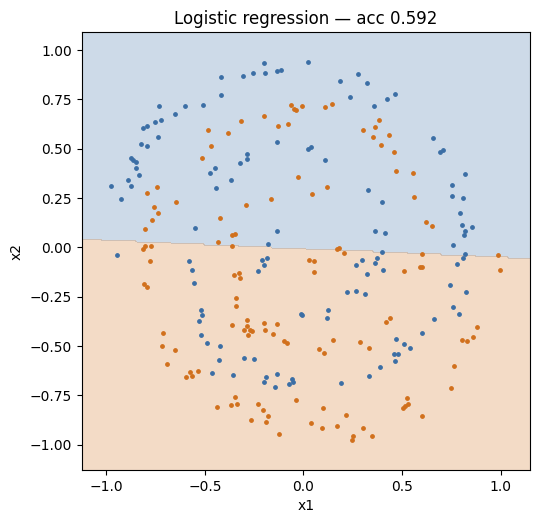

In [41]:
def plot_boundary(model, X, y, title, transform=None, ax=None):
    """Shade the model's decision regions and overlay the data.

    transform : optional callable applied to grid points before predicting,
                used when the model was fitted on engineered features.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(5.5, 5.5))
    pad = 0.15
    x1g = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 300)
    x2g = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 300)
    G1, G2 = np.meshgrid(x1g, x2g)
    grid = np.column_stack([G1.ravel(), G2.ravel()])
    Z = model.predict(grid if transform is None else transform(grid)).reshape(G1.shape)
    ax.contourf(G1, G2, Z, alpha=0.25, levels=1, colors=["#3b6ea5", "#d1701c"])
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=6, c="#3b6ea5")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=6, c="#d1701c")
    ax.set_title(title); ax.set_aspect("equal")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    return ax


plot_boundary(linear, X_test, y_test, f"Logistic regression — acc {acc_linear:.3f}")
plt.tight_layout(); plt.show()

Around 0.59. Barely better than a coin flip, and the picture shows exactly why: one flat blue region, one flat orange region, a single straight seam between them.

Here is the part that matters most, and it is easy to skim past.

**Nothing is broken.** The data loaded correctly. The labels are perfect. There is no missing data, no leakage, no imbalance. The optimiser converged. There is no bug in the code. The model did precisely what it was designed to do, and the task was simply outside its reach.

That distinction — between *a model that failed* and *a model class that cannot express the answer* — is one of the most useful diagnostic instincts you will build in this course. On Day 3 you will need it constantly.

**Questions to sit with.**

1. If the model is not at fault and the code is not at fault, what exactly is?
2. Would collecting ten times more spiral data improve this result? Why or why not?
3. Would a linear SVM do better? What about a decision tree — and why is the tree a different kind of answer?

## 4. Fixing it by hand: engineering the features yourself

You are not stuck. You have a whole professional toolkit for exactly this situation, and you have used it many times: **if the model cannot express the boundary in the current feature space, change the feature space.**

Go back to how you described the rule in Section 2. You almost certainly reached for *distance from the centre* and *angle around the centre*. That instinct is correct, and we can write it down.

Each point has a radius $r = \sqrt{x_1^2 + x_2^2}$ and an angle $\theta = \arctan2(x_2, x_1)$. Now here is the piece of domain knowledge that unlocks the problem. We built the spirals so that a point's angle grows in lockstep with its radius — that is what makes it a spiral rather than a circle. So if we *subtract off* the rotation that the radius accounts for, what remains should depend only on which arm the point belongs to.

Define an aligned angle:

$$\alpha = \theta - r \cdot (\text{revolutions} \times 2\pi)$$

For one arm $\alpha$ lands near $0$, for the other near $\pi$. Feed the model $\sin\alpha$ and $\cos\alpha$ and the two classes pull apart cleanly. We use sine and cosine rather than $\alpha$ itself because angles wrap around, and a raw wrapped angle would put nearby points at opposite ends of the number line.

This is unrolling the spiral into a straight strip. Same points, same labels, different description.

In [50]:
def polar_features(Z, revolutions=REVOLUTIONS):
    """Hand-designed features that encode our knowledge of the spiral geometry."""
    r = np.sqrt(Z[:, 0] ** 2 + Z[:, 1] ** 2)
    theta = np.arctan2(Z[:, 1], Z[:, 0])
    alpha = theta - r * (revolutions * 2 * np.pi)   # remove the rotation the radius explains
    return np.column_stack([Z, r, np.sin(alpha), np.cos(alpha)])

In [11]:
X_train

array([[-0.37011545,  0.38877092],
       [-0.454673  , -0.20032154],
       [ 0.47800824, -0.21109596],
       ...,
       [-0.06792554,  0.27678796],
       [ 0.37904385,  0.40279626],
       [ 0.38958808, -0.18715052]], shape=(750, 2))

In [51]:
polar_features(X_train)

array([[-0.37011545,  0.38877092,  0.53677581,  0.18212516,  0.98327536],
       [-0.454673  , -0.20032154,  0.49684631,  0.89403051, -0.44800608],
       [ 0.47800824, -0.21109596,  0.5225451 , -0.71791249, -0.69613336],
       ...,
       [-0.06792554,  0.27678796,  0.2850008 , -0.45845638, -0.88871691],
       [ 0.37904385,  0.40279626,  0.55309951, -0.99983226, -0.01831514],
       [ 0.38958808, -0.18715052,  0.4322085 , -0.81559639,  0.57862123]],
      shape=(750, 5))

In [52]:
linear_fe = LogisticRegression(max_iter=3000).fit(polar_features(X_train), y_train)
acc_fe = accuracy_score(y_test, linear_fe.predict(polar_features(X_test)))


print(f"Logistic regression, engineered features: {acc_fe:.3f}")

Logistic regression, engineered features: 0.992


In [53]:
print(f"Logistic regression, raw features:        {acc_linear:.3f}")

Logistic regression, raw features:        0.592


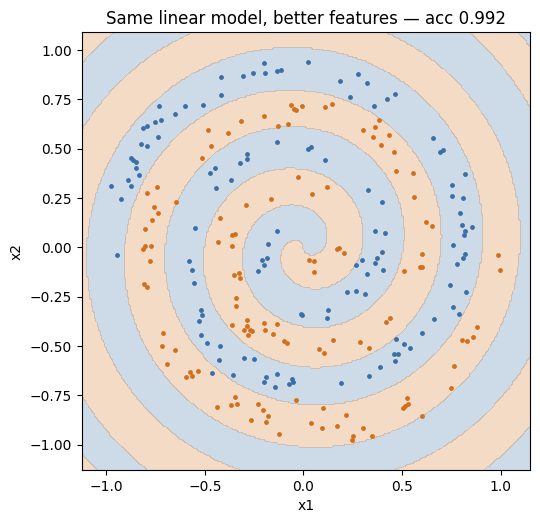

In [54]:
plot_boundary(linear_fe, X_test, y_test,
              f"Same linear model, better features — acc {acc_fe:.3f}",
              transform=polar_features)
plt.tight_layout(); plt.show()

From 0.59 to 0.99. The *model* never changed — it is the same logistic regression, still drawing a single straight line. What changed is the space it draws that line in. In the aligned-angle space, one straight cut is all the problem ever needed.

This is worth stating plainly because it is the hinge of the whole argument:

> The limitation was never in the classifier. It was in the representation.

**Questions.**

1. The engineered version beats the network we are about to train. Is engineering features therefore the better technique here?
2. How much did you need to know about how the data was generated to invent `alpha`? Could you have derived it from the scatter plot alone?
3. What happens to `polar_features` if the spirals are not centred at the origin?

## 5. Who invented those features?

**`You did.`**

And that is fine — for this problem. You could see the data in two dimensions, you knew the generating process, and the geometry was simple enough to reason about over a coffee. Under those conditions, hand-engineering is not merely acceptable, it is often the *superior* engineering decision: it is fast, cheap, interpretable, and it encodes real knowledge that no amount of data can supply.

So ask the uncomfortable question. What are the actual preconditions for what you just did?

- You could **visualise** the data. Two dimensions. Now imagine 4,096.
- You **knew the generating process**. You wrote it. Real data rarely comes with its equations attached.
- The right transformation was **compact** — one line of trigonometry. Not every structure compresses that well.
- The features were **stable**. Change the centre, the number of revolutions, or the noise level and `polar_features` degrades.

Strip away any one of those and the approach starts to strain. Strip away all four — which is the normal condition for images, audio, and text — and it collapses entirely. Section 10 shows you exactly what that collapse looks like.

This is the gap deep learning was built to fill. Not "features are bad." Rather: **when you cannot invent the features, you need a method that discovers them from the data, as part of solving the task.**

**Question.** Think about a domain you know well. Roughly how long would it take a newcomer to learn the features that experts in that domain consider obvious? That duration is a rough estimate of what representation learning is trying to compress.

## 6. A small network finds them on its own

Now we hand a neural network the *raw* `x1` and `x2` columns. No radius. No angle. No trigonometry. Nothing of what you worked out in Section 4.

We use scikit-learn's `MLPClassifier` here deliberately, because the point of this section is the *result*, not the mechanism. Note 1.2 opens up the mechanism by hand, and Note 1.3 rebuilds it in PyTorch. For now, treat it as a black box that we are about to justify opening.

In [55]:
from sklearn.neural_network import MLPClassifier
import time

In [56]:
t0 = time.time()
net = MLPClassifier(
    hidden_layer_sizes=(64, 64),   # two hidden layers, 64 units each
    activation="relu",
    learning_rate_init=0.01,
    max_iter=6000,
    random_state=0,
).fit(X_train, y_train)                # <-- raw x1, x2 only
train_time = time.time() - t0

In [57]:
acc_net = accuracy_score(y_test, net.predict(X_test))

In [59]:
acc_net

0.952

In [58]:
n_params = sum(w.size for w in net.coefs_) + sum(b.size for b in net.intercepts_)

print(f"Linear, raw features:        {acc_linear:.3f}")
print(f"Linear, engineered features: {acc_fe:.3f}   <- required your domain knowledge")
print(f"Neural network, raw features:{acc_net:.3f}   <- required none")
print(f"\nNetwork parameters: {n_params:,}   |  training time: {train_time:.1f}s")

Linear, raw features:        0.592
Linear, engineered features: 0.992   <- required your domain knowledge
Neural network, raw features:0.952   <- required none

Network parameters: 4,417   |  training time: 0.2s


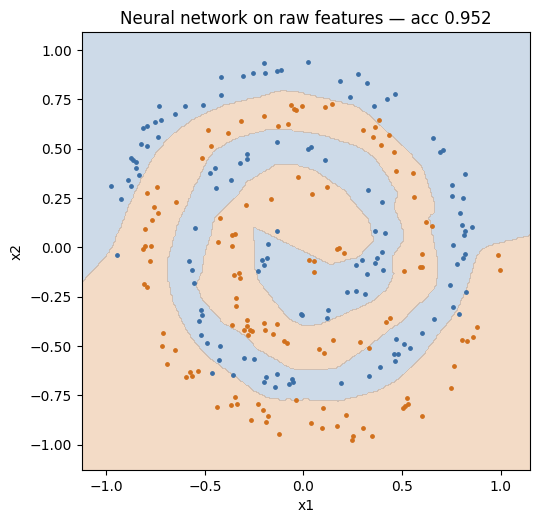

In [19]:
plot_boundary(net, X_test, y_test, f"Neural network on raw features — acc {acc_net:.3f}")
plt.tight_layout(); plt.show()

The boundary curves. It wraps around the arms, follows the spiral outward, and does so without anyone telling it that spirals have a radius and an angle.

Something specific happened inside that model, and naming it correctly matters more than being impressed by it. The network's first layer transformed `(x1, x2)` into 64 new numbers. The second layer transformed those into 64 more. Only the final layer performed the classification — and it is, in essence, a logistic regression, exactly like the one that failed in Section 3.

So the last layer is the same model that could not solve this problem. What changed is that it now sits on top of a representation the network built for itself. **The earlier layers are the feature engineering.** They were fitted, not written.

<div align="center">

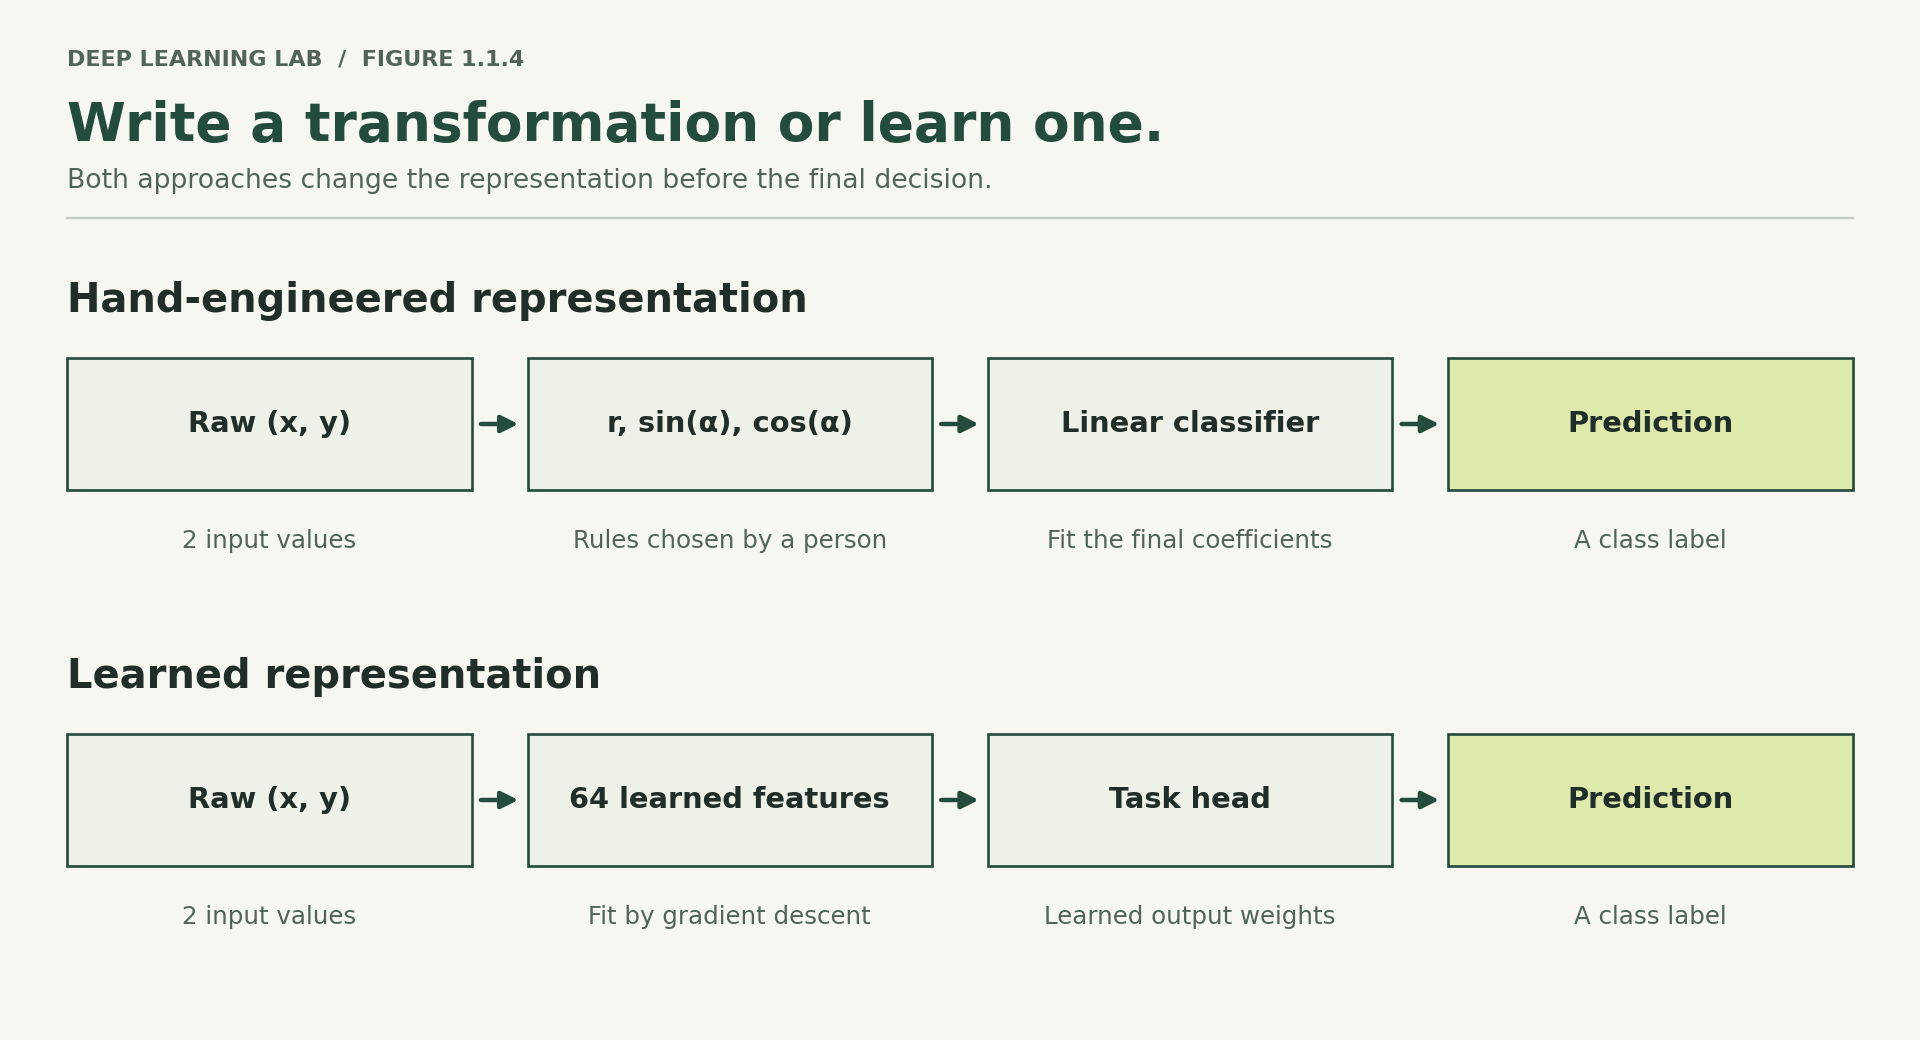

<p><b>Figure 1.1.4.</b> The lesson compares hand-designed polar features with a learned hidden representation. The encoder and head are trained together in the neural network.</p>

</div>

**Questions.**

1. The network reached 0.95 while your engineered features reached 0.99. Which approach would you defend in a design review, and what would decide it?
2. The network used roughly 4,000 parameters to learn what you expressed in three. What did it buy with that extra capacity?
3. What would happen if you trained this same network on 50 points instead of 1,000? Try it — change `n_per_class` and re-run. The result is the seed of a lesson we return to on Day 7.

## 7. The honest counterexample: churn, where the network wins nothing

If this note stopped at Section 6, you would leave with a conclusion that is both tidy and wrong: *neural networks learn their own features, therefore neural networks are better.*

They are not better. They are **different**, and the difference pays off only under specific conditions. The fastest way to see this is to run the comparison on the kind of data most working data scientists actually face.

We use the Telco Customer Churn dataset — 7,043 customers, 20 predictors, a binary churn label. It is tabular, mixed categorical and numeric, moderately imbalanced. If you have worked in industry, you have met a dozen datasets shaped exactly like this.

Both models get the same split, the same preprocessing, and a fair shot.

In [60]:
URLS = [
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv",
    "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv",
]

churn = None
for url in URLS:
    try:
        churn = pd.read_csv(url)
        print(f"Loaded from: {url.split('/')[4]}")
        break
    except Exception as e:
        print(f"  failed ({type(e).__name__}), trying next mirror...")

if churn is None:
    raise RuntimeError("Could not download the dataset. Check your internet connection.")

print("shape:", churn.shape)
churn.head(3)

Loaded from: telco-customer-churn-on-icp4d
shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [61]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [63]:
# TotalCharges arrives as text with blanks for brand-new customers
churn["TotalCharges"] = pd.to_numeric(churn["TotalCharges"], errors="coerce").fillna(0.0)

y_churn = (churn["Churn"] == "Yes").astype(int).values
X_churn = pd.get_dummies(churn.drop(columns=["customerID", "Churn"]), drop_first=True).astype(float)

print("features after one-hot encoding:", X_churn.shape[1])
print("churn rate:", f"{y_churn.mean():.1%}")

features after one-hot encoding: 30
churn rate: 26.5%


In [64]:
X_churn

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1.0,29.85,29.85,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,34.0,56.95,1889.50,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,2.0,53.85,108.15,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,45.0,42.30,1840.75,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,2.0,70.70,151.65,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,24.0,84.80,1990.50,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
7039,0.0,72.0,103.20,7362.90,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0
7040,0.0,11.0,29.60,346.45,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
7041,1.0,4.0,74.40,306.60,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [65]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_churn.values, y_churn, test_size=0.25, random_state=0, stratify=y_churn
)

In [66]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# Gradient boosting: no scaling needed, handles mixed feature scales natively
t0 = time.time()
gbdt = HistGradientBoostingClassifier(random_state=0).fit(Xc_train, yc_train)
gbdt_time = time.time() - t0
gbdt_auc = roc_auc_score(yc_test, gbdt.predict_proba(Xc_test)[:, 1])

In [67]:
gbdt_auc

0.829237396119133

In [74]:
# Neural network: scaling is NOT optional here — we will return to why on Day 3
scaler = StandardScaler().fit(Xc_train)
t0 = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=0)
mlp.fit(scaler.transform(Xc_train), yc_train)
mlp_time = time.time() - t0
mlp_auc = roc_auc_score(yc_test, mlp.predict_proba(scaler.transform(Xc_test))[:, 1])

In [75]:
mlp_auc

0.7738739827038977

In [76]:
print(f"{'model':<22}{'ROC-AUC':>10}{'train time':>14}")
print("-" * 46)
print(f"{'Gradient boosting':<22}{gbdt_auc:>10.4f}{gbdt_time:>13.1f}s")
print(f"{'Neural network':<22}{mlp_auc:>10.4f}{mlp_time:>13.1f}s")

model                    ROC-AUC    train time
----------------------------------------------
Gradient boosting         0.8292          2.8s
Neural network            0.7739          2.0s


Gradient boosting wins on quality *and* costs roughly a tenth of the training time. It also needed no feature scaling, exposes feature importances for free, and has far fewer knobs to get wrong.

This is not a fluke of one dataset or one seed. On medium-sized tabular data with meaningful engineered columns, gradient-boosted trees remain a genuinely strong default in 2026 — a fact that survives every wave of deep learning enthusiasm, and one that experienced practitioners take for granted.

Why? The spiral had **geometric structure in raw coordinates** that a network could exploit. The churn table does not. Its columns are already meaningful, human-curated quantities — tenure, monthly charge, contract type. Someone already did the representation learning, by hand, when they designed the database schema. There is very little left for a network to discover.

That gives you a usable heuristic, and it is worth committing to memory:

> Deep learning pays off where the raw signal is high-dimensional, redundant, and structured in ways humans cannot easily write down — pixels, waveforms, text. On well-curated tabular data, it frequently does not.

**Questions.**

1. Your manager asks for a churn model by Friday. Which do you build, and what would change your answer?
2. Under what circumstances *would* you expect a network to beat gradient boosting on tabular data?
3. We tuned neither model. Does that weaken the conclusion? What would a fair comparison require? Hold that thought — it is the whole of Day 4.

## 8. What actually changed

Three experiments, three results. Let us extract the principle carefully, because loose versions of it are everywhere and most of them are wrong.

| | Feature engineering | Model | Result |
|---|---|---|---|
| Spirals, linear | You wrote `r`, `sin α`, `cos α` | Logistic regression | 0.99 |
| Spirals, network | None | 2-layer network | 0.95 |
| Churn, boosting | Schema designers, years ago | Gradient boosting | 0.829 AUC |
| Churn, network | Same schema | 2-layer network | 0.774 AUC |

Here is the principle:

> **Representation learning means the transformation from raw input to useful description is *learned from data*, jointly with the task, rather than specified in advance by a person.**

Three things this does *not* say, each corresponding to a claim you will encounter and should push back on:

- It does not say feature engineering is obsolete. Section 4 outperformed Section 6.
- It does not say networks always win. Section 7 says the opposite, on the data type most companies hold most of.
- It does not say the work vanishes. It moves — into architecture choice, data preparation, and training dynamics. Days 2 through 4 are about that relocated work.

What it *does* say is that a door opened. Once representations are learnable, you can attack problems where nobody knows how to write the features down — and you can reuse a representation learned on one task for a different task. That second consequence is transfer learning, it is the basis of every pretrained model you will touch from Day 7 onward, and it is why this idea matters far beyond the accuracy numbers above.

**Question.** Rewrite the principle above in your own words, in two sentences, without using the words "features" or "representation". If you cannot, reread the table.

## 9. Where feature engineering still lives in deep learning

A tempting summary of Section 6 is that the network needed no preparation. That is false, and believing it will cost you real time on Day 3.

Watch what happens when we remove one preprocessing step from the churn network — the standardisation that we quietly applied.

In [77]:
mlp_unscaled = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=0)
mlp_unscaled.fit(Xc_train, yc_train)          # same model, same data, NO scaling
auc_unscaled = roc_auc_score(yc_test, mlp_unscaled.predict_proba(Xc_test)[:, 1])

print(f"Neural network, standardised inputs: {mlp_auc:.4f}")
print(f"Neural network, raw inputs:          {auc_unscaled:.4f}")
print(f"\nDamage from skipping one preprocessing step: {mlp_auc - auc_unscaled:.4f} AUC")
print(f"\nFeature ranges in the raw data:")
print(f"  tenure:        {Xc_train[:, X_churn.columns.get_loc('tenure')].min():.1f} to "
      f"{Xc_train[:, X_churn.columns.get_loc('tenure')].max():.1f}")
print(f"  TotalCharges:  {Xc_train[:, X_churn.columns.get_loc('TotalCharges')].min():.1f} to "
      f"{Xc_train[:, X_churn.columns.get_loc('TotalCharges')].max():.1f}")

Neural network, standardised inputs: 0.7739
Neural network, raw inputs:          0.7794

Damage from skipping one preprocessing step: -0.0056 AUC

Feature ranges in the raw data:
  tenure:        0.0 to 72.0
  TotalCharges:  0.0 to 8672.5


One column spans single digits, another spans thousands. Gradient descent takes steps that are the same size in every direction, so a feature measured in thousands dominates the update and a feature measured in tens is effectively ignored for a long time. Day 3 makes this precise. For now, note the empirical fact: the "no feature engineering needed" model lost real performance from a missing three-line transformation.

So where does the human work actually live in a deep learning project in 2026?

- **Input scaling and normalisation** — never optional, as you just measured.
- **Data quality and labelling** — the single largest lever on final performance, and Day 8 is devoted to it.
- **Architecture choice** — a convolution encodes "nearby pixels are related"; attention encodes "any token may relate to any other". These are engineered inductive biases, chosen by you.
- **Tokenisation** for text, sample rate for audio, image resizing and augmentation for vision — all human decisions made before the model sees anything.
- **Loss design** — what you optimise defines what you get.

The work did not disappear. It changed shape, and it moved up a level of abstraction.

**Question.** Of the five items above, which do you think is most often responsible for a deep learning project underperforming in production? Write your answer down and revisit it on Day 8.

## 10. Raw pixels: the point of no return

The spirals had two features. You could plot them, reason about them, and invent a transformation over lunch. Now we scale the input up, and the argument stops being a matter of taste.

These are 8×8 handwritten digits — 64 pixels each, the smallest realistic image data that exists. Modern images are hundreds of times larger.

In [78]:
from sklearn.datasets import load_digits

digits = load_digits()
print("images:", digits.images.shape, " -> flattened:", digits.data.shape)
print("classes:", np.unique(digits.target))

images: (1797, 8, 8)  -> flattened: (1797, 64)
classes: [0 1 2 3 4 5 6 7 8 9]


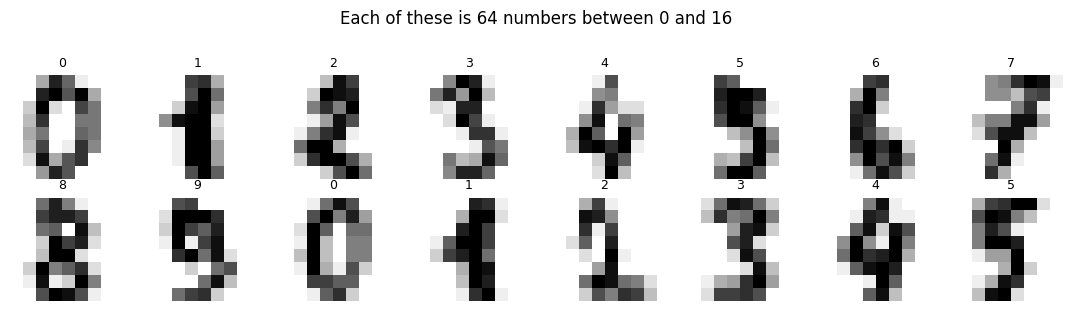

In [79]:
fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for ax, img, label in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(img, cmap="gray_r"); ax.set_title(str(label), fontsize=9); ax.axis("off")
plt.suptitle("Each of these is 64 numbers between 0 and 16", y=1.02)
plt.tight_layout(); plt.show()

Now try to do what you did in Section 4. Write a feature that separates 3 from 8.

Not a model — a *feature*. An explicit arithmetic function of those 64 pixel values that is reliably larger for one digit than the other. Give yourself two honest minutes before running the next cell.

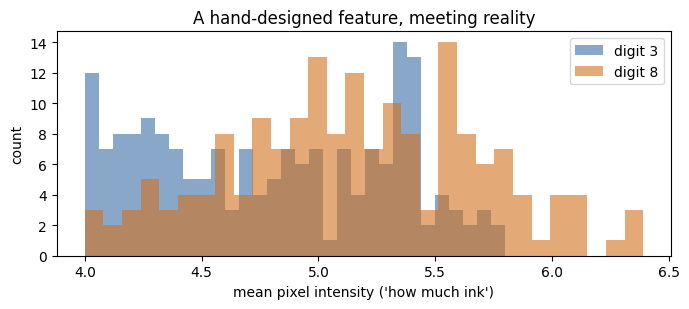

Accuracy from 'total ink' alone, 3 vs 8: 0.625


In [31]:
# The kind of feature a person actually reaches for first: overall darkness.
ink = digits.data.mean(axis=1)

mask = np.isin(digits.target, [3, 8])
ink_38, lab_38 = ink[mask], digits.target[mask]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(ink_38[lab_38 == 3], bins=30, alpha=0.6, label="digit 3", color="#3b6ea5")
ax.hist(ink_38[lab_38 == 8], bins=30, alpha=0.6, label="digit 8", color="#d1701c")
ax.set_xlabel("mean pixel intensity ('how much ink')"); ax.set_ylabel("count")
ax.set_title("A hand-designed feature, meeting reality"); ax.legend()
plt.tight_layout(); plt.show()

# How far does that one feature get us?
thresh = ink_38.mean()
pred = np.where(ink_38 > thresh, 8, 3)
print(f"Accuracy from 'total ink' alone, 3 vs 8: {(pred == lab_38).mean():.3f}")

The distributions sit almost on top of each other. And this was the *easy* pair, on 8×8 images, distinguishing only two classes.

Now consider what you are actually up against. Distinguishing all ten digits needs features robust to stroke thickness, slant, position, size and writing style. A 224×224 colour photograph has 150,528 numbers. The pixel at position 9,412 means nothing on its own — meaning lives in relationships between pixels, across many scales at once, and those relationships shift when the object moves two pixels to the left.

No one hand-writes that. People genuinely tried, for decades, with real ingenuity — SIFT, HOG, wavelet banks, Gabor filters. Those were serious engineering achievements, and learned representations comprehensively outperformed them.

<div align="center">

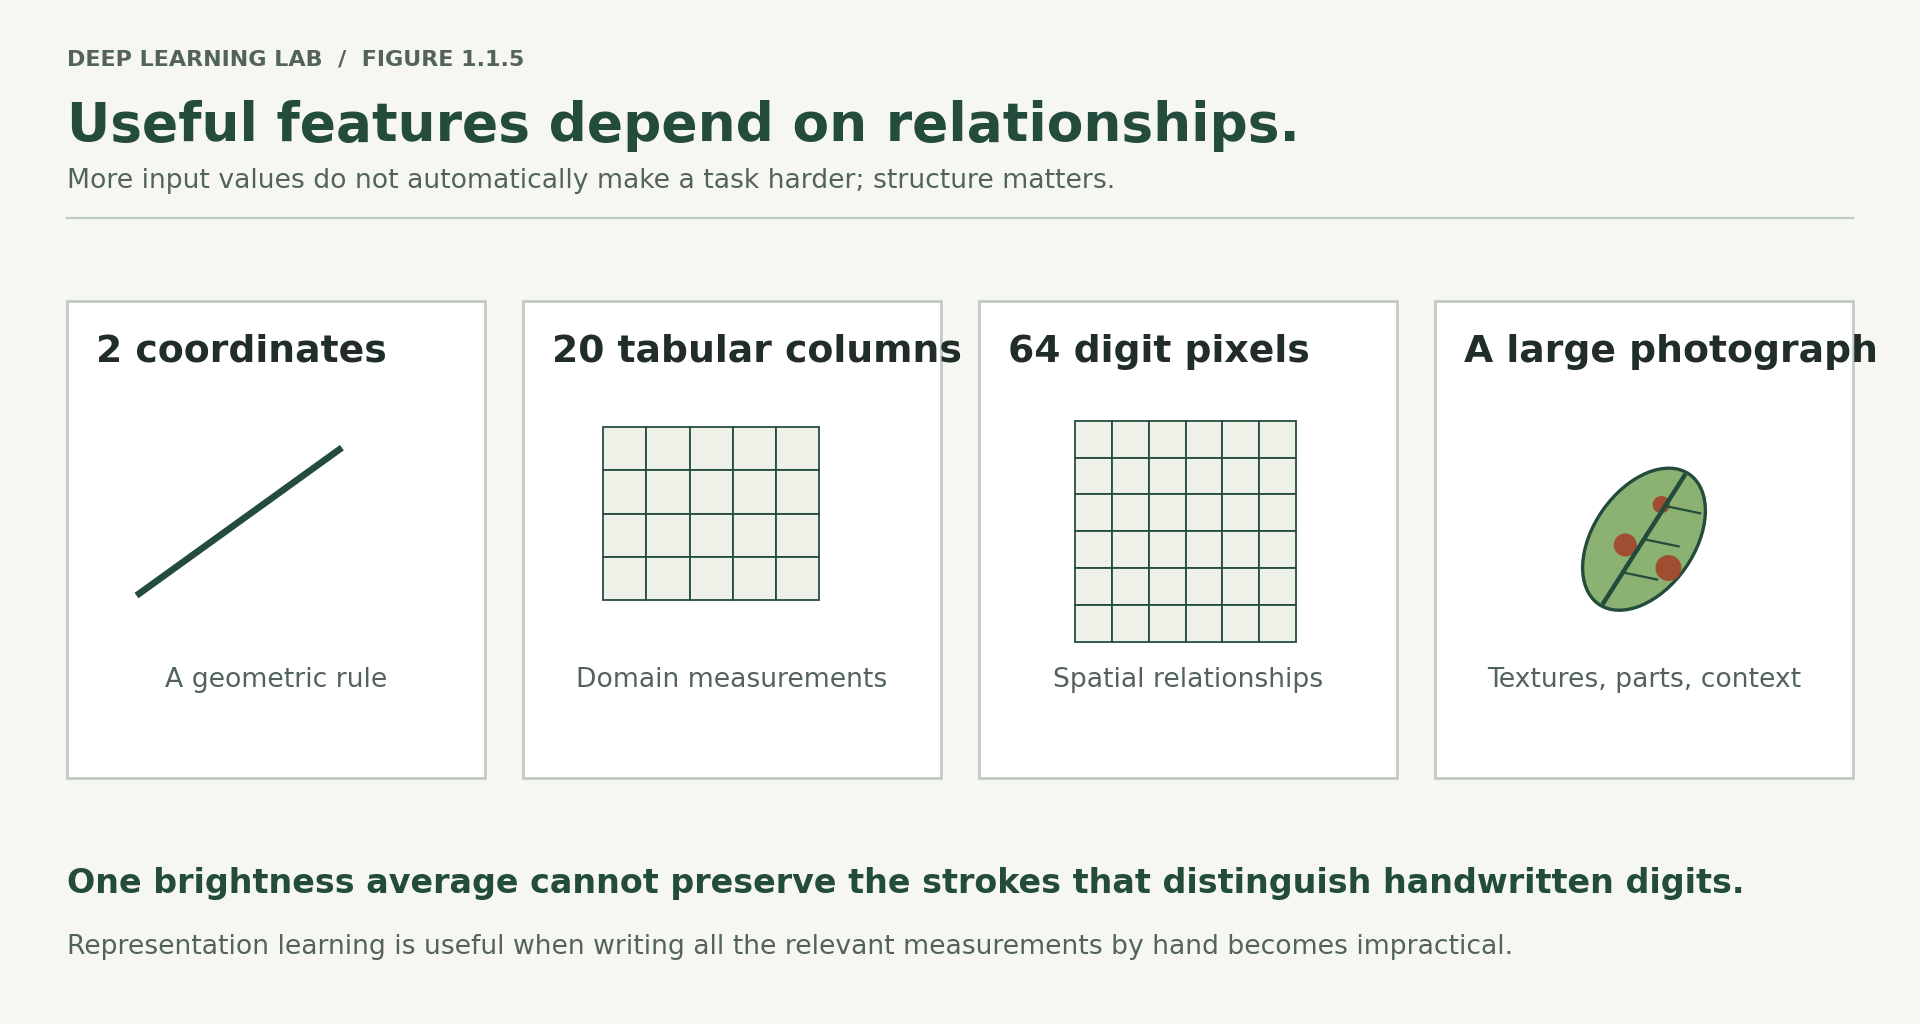

<p><b>Figure 1.1.5.</b> A task’s useful information can live in relationships between values. The panels are examples, not a universal dimensionality threshold for deep learning.</p>

</div>

**Questions.**

1. Why does the pixel at a fixed position carry so little information on its own?
2. Digit images are centred and size-normalised. What breaks if they are not?
3. Given the difficulty above, why does a network learning these features from scratch not seem hopeless? What does it have that you do not?

## 11. What this course is, and what it is not

You now have the argument in full, so it is worth being explicit about what the next nine days will and will not do.

**This course is** the engineering layer between the classical machine learning you already know and the generative AI work that follows. The question it answers is: *how does an AI engineer take a neural network or a pretrained model from raw data to a working, evaluated, deployable system?*

**This course is not** a mathematics course. You will trace backpropagation by hand in Note 1.2 because doing so makes training failures debuggable, not because derivations are the goal. There will be no proofs.

**It is not a history course.** Convolutional networks and recurrent networks receive proportionate conceptual treatment on Day 5 — enough to understand why they mattered and what replaced them.

**It is not an LLM applications course.** Retrieval, agents, and tool use belong to the Generative AI module that follows. Here we build the foundation those systems stand on.

**It is not a model zoo tour.** Fewer models, understood properly, beats many models demonstrated superficially.

And it is deliberately hands-on. Somewhere between half and two-thirds of your time will be spent writing, running, breaking and debugging code — which is where the understanding actually forms.

One habit to start today, since Day 10 will ask for it as a deliverable: keep a short log of every experiment. What did I try, why, what happened, what did I learn, what would I change? Four lines per experiment. This single practice separates engineers who improve steadily from those who keep rediscovering the same result.

## 12. Conclusion

Three experiments, one idea.

A linear model failed on the spirals not through any defect but because a straight line cannot express the answer. You fixed it by inventing better features — which worked beautifully, and required you to know how the data was generated. A network then reached comparable accuracy from raw coordinates alone, having built its own intermediate description of the data as part of learning the task. And on churn, where humans had already curated the features into the schema, gradient boosting beat the network on both accuracy and time.

So the shift is not that deep learning is stronger. It is that **the transformation from raw input to useful description became something that could be learned rather than written** — which matters most exactly where writing it is hopeless, and matters least where it has already been done well.

That is also the seed of everything ahead. If representations can be learned, they can be learned once on enormous data and reused. That is pretraining, that is transfer learning, and that is why a model trained by someone else in 2024 can be adapted to your problem on a free Colab GPU in an afternoon.

**Check yourself.** You should now be able to answer, without looking back:

- Why did logistic regression fail on the spirals, and why was that not a bug?
- What is the difference between a learned parameter and an engineered feature?
- Name a situation in 2026 where you would choose gradient boosting over a neural network, and defend it.
- Where does human engineering effort still go in a deep learning project?

## Transition to Note 1.2

You have watched a network learn features. You have not the faintest idea how.

That is the honest position at this point, and it is exactly where Note 1.2 begins. We shrink the problem down to a network with six parameters and four training examples — small enough that you will compute every single number yourself, on paper if you like. Forward pass by hand. Loss by hand. Gradients by hand. One parameter update by hand.

Then, at the very end, we hand the same numbers to PyTorch and check its arithmetic against yours.

They will match exactly. From that point on, `loss.backward()` stops being a magic incantation and becomes a function whose output you could have produced yourself — which is precisely the position you need to be in when a training run silently fails on Day 3.

**Next:** `Note_1_2_The_Learning_Mechanism.ipynb`